# Lab 08 — Sentiment Classification using RNN & LSTM
**Dataset:** Stanford Sentiment Treebank 2 (SST-2) via HuggingFace  
**Task:** Binary sentiment classification of movie reviews (positive / negative)


## 1. Install Dependencies

In [24]:
# Run once — comment out after first install
#!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn datasets pyarrow


In [25]:
#!pip install datasets

## 2. Imports & Configuration

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, random, warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyperparameters ──────────────────────────────────────────────────────
MAX_VOCAB  = 20_000
MAX_LEN    = 64
EMBED_DIM  = 64
RNN_UNITS  = 64
DROPOUT    = 0.4
BATCH_SIZE = 64
EPOCHS     = 10
TEST_SIZE  = 5_000

print("TensorFlow :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow : 2.19.0
GPU devices: []


## 3. Load Dataset from HuggingFace
Downloads SST-2 automatically on first run (~5 MB). Cached locally after that.


In [27]:
from datasets import load_dataset

print("Loading SST-2 from HuggingFace...")
ds = load_dataset("stanfordnlp/sst2")

train_full = ds['train'].to_pandas()
val_df     = ds['validation'].to_pandas()

# Keep only the columns we need
train_full = train_full[['sentence', 'label']]
val_df     = val_df[['sentence', 'label']]

print(f"Train shape      : {train_full.shape}")
print(f"Validation shape : {val_df.shape}")
train_full.head()


Loading SST-2 from HuggingFace...
Train shape      : (67349, 2)
Validation shape : (872, 2)


,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


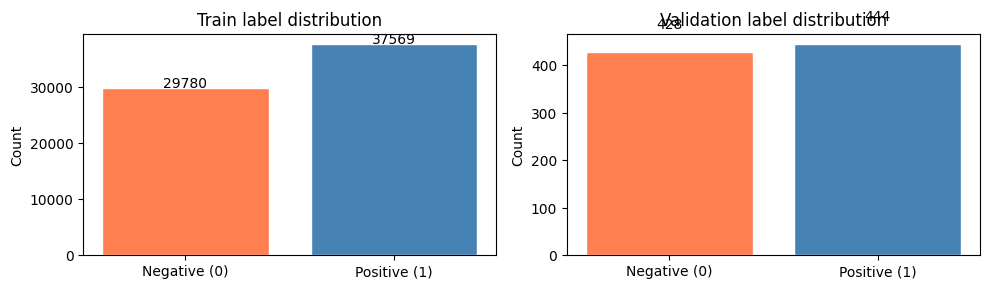

In [28]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, df, title in zip(axes, [train_full, val_df], ['Train', 'Validation']):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
           color=['coral', 'steelblue'], edgecolor='white')
    ax.set_title(f'{title} label distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 4. Train / Test Split
Split train rows → **5 000 test** + **~62 349 train** (stratified)

In [29]:
train_df, test_df = train_test_split(
    train_full, test_size=TEST_SIZE, random_state=SEED, stratify=train_full['label']
)

print(f"Train : {len(train_df):,}")
print(f"Test  : {len(test_df):,}")
print(f"Val   : {len(val_df):,}")

X_train, y_train = train_df['sentence'].tolist(), train_df['label'].tolist()
X_val,   y_val   = val_df['sentence'].tolist(),   val_df['label'].tolist()
X_test,  y_test  = test_df['sentence'].tolist(),  test_df['label'].tolist()


Train : 62,349
Test  : 5,000
Val   : 872


## 5. NLP Preprocessing

| Step | What it does |
|---|---|
| Lowercasing | Reduces vocab size ("The" and "the" → same token) |
| Punctuation removal | Removes noise characters |
| Tokenisation | Splits sentence into word tokens |
| Vocabulary building | Maps each word → unique integer ID |
| Padding | Makes all sequences the same fixed length |


In [30]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train_clean = [clean_text(s) for s in X_train]
X_val_clean   = [clean_text(s) for s in X_val]
X_test_clean  = [clean_text(s) for s in X_test]

print("Original :", X_train[0])
print("Cleaned  :", X_train_clean[0])


Original : comes the first lousy guy ritchie imitation 
Cleaned  : comes the first lousy guy ritchie imitation


In [31]:
# Fit tokeniser only on training data (avoid data leakage)
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_clean)

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"Vocabulary size : {vocab_size:,}")

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_enc = encode(X_train_clean)
X_val_enc   = encode(X_val_clean)
X_test_enc  = encode(X_test_clean)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print("X_train_enc :", X_train_enc.shape)
print("X_val_enc   :", X_val_enc.shape)
print("X_test_enc  :", X_test_enc.shape)


Vocabulary size : 14,664
X_train_enc : (62349, 64)
X_val_enc   : (872, 64)
X_test_enc  : (5000, 64)


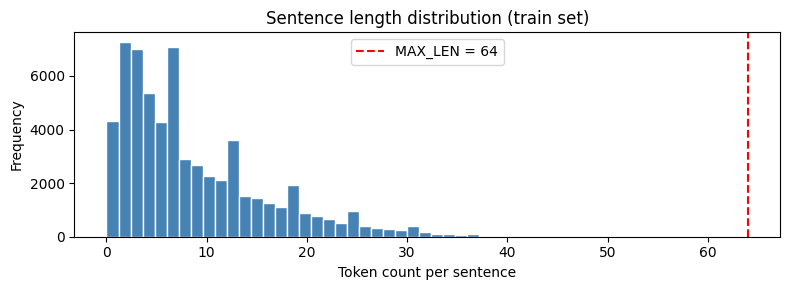

Max: 48  |  95th percentile: 24


In [32]:
# Sentence length distribution
raw_lens = [len(s.split()) for s in X_train_clean]
plt.figure(figsize=(8, 3))
plt.hist(raw_lens, bins=40, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.xlabel('Token count per sentence')
plt.ylabel('Frequency')
plt.title('Sentence length distribution (train set)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Max: {max(raw_lens)}  |  95th percentile: {np.percentile(raw_lens, 95):.0f}")


## 6. Model A — Simple RNN

```
Input → Embedding → SimpleRNN → Dropout → Dense(sigmoid)
```


In [33]:
def build_rnn(vocab_size, embed_dim, rnn_units, max_len, dropout):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(vocab_size, embed_dim, mask_zero=True),
        layers.SimpleRNN(rnn_units),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ], name='SimpleRNN_Sentiment')
    return model

rnn_model = build_rnn(vocab_size, EMBED_DIM, RNN_UNITS, MAX_LEN, DROPOUT)
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()


Model: "SimpleRNN_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 64, 64)         │       938,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946,817 (3.61 MB)

 Trainable params: 946,817 (3.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

history_rnn = rnn_model.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.7565 - loss: 0.4733 - val_accuracy: 0.8165 - val_loss: 0.4724 - learning_rate: 0.0010
Epoch 2/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.9304 - loss: 0.1940 - val_accuracy: 0.8039 - val_loss: 0.6039 - learning_rate: 0.0010
Epoch 3/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.9556 - loss: 0.1290 - val_accuracy: 0.8028 - val_loss: 0.7130 - learning_rate: 0.0010
Epoch 4/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9670 - loss: 0.1017
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
975/975 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.9670 - loss: 0.1017 - val_accuracy: 0.7867 - val_loss: 0.7933 - learning_rate: 0.0010
Epoch 5/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.9739 - loss: 0.0781 - val_accuracy: 0.7924 - val_loss: 0.9606 - learning_rate: 5.0000e-04
Epoch 6/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9793 -

## 7. Model B — LSTM

```
Input → Embedding → LSTM → Dropout → Dense(sigmoid)
```

LSTM introduces **forget, input, and output gates** that regulate information flow,
solving the vanishing gradient problem that limits SimpleRNN on longer sequences.


In [35]:
def build_lstm(vocab_size, embed_dim, rnn_units, max_len, dropout):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(vocab_size, embed_dim, mask_zero=True),
        layers.LSTM(rnn_units),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ], name='LSTM_Sentiment')
    return model

lstm_model = build_lstm(vocab_size, EMBED_DIM, RNN_UNITS, MAX_LEN, DROPOUT)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()


Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 64, 64)         │       938,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971,585 (3.71 MB)

 Trainable params: 971,585 (3.71 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_lstm = lstm_model.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 75s 74ms/step - accuracy: 0.7657 - loss: 0.4630 - val_accuracy: 0.8257 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 2/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 111s 103ms/step - accuracy: 0.9236 - loss: 0.2024 - val_accuracy: 0.8234 - val_loss: 0.4806 - learning_rate: 0.0010
Epoch 3/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.9493 - loss: 0.1385 - val_accuracy: 0.8165 - val_loss: 0.5351 - learning_rate: 0.0010
Epoch 4/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9606 - loss: 0.1039
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
975/975 ━━━━━━━━━━━━━━━━━━━━ 103s 105ms/step - accuracy: 0.9606 - loss: 0.1039 - val_accuracy: 0.8142 - val_loss: 0.5869 - learning_rate: 0.0010
Epoch 5/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 946s 972ms/step - accuracy: 0.9708 - loss: 0.0757 - val_accuracy: 0.8211 - val_loss: 0.8026 - learning_rate: 5.0000e-04
Epoch 6/10
975/975 ━━━━━━━━━━━━━━━━━━━━ 86s 88ms/step - accuracy: 0

## 8. Training Curves

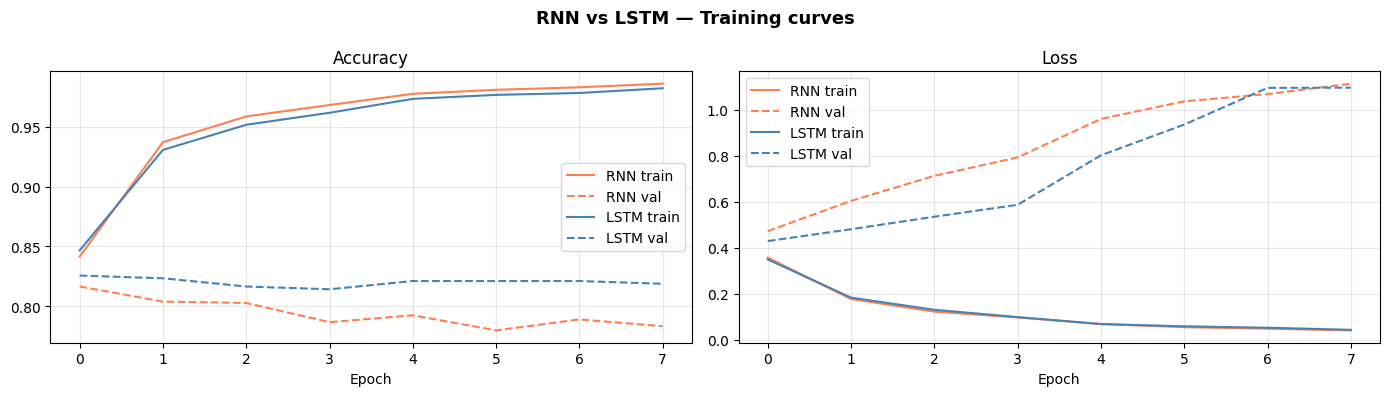

In [37]:
def plot_history(h_rnn, h_lstm):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(h_rnn.history[metric],          label='RNN train',  color='coral')
        ax.plot(h_rnn.history[f'val_{metric}'], label='RNN val',    color='coral',     linestyle='--')
        ax.plot(h_lstm.history[metric],         label='LSTM train', color='steelblue')
        ax.plot(h_lstm.history[f'val_{metric}'],label='LSTM val',   color='steelblue', linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle('RNN vs LSTM — Training curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_rnn, history_lstm)


## 9. Evaluation on Test Set (5 000 rows)

In [38]:
def evaluate_model(model, X, y, name):
    y_pred = (model.predict(X, verbose=0).ravel() >= 0.5).astype(int)
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred), 4),
        'Recall'   : round(recall_score(y, y_pred), 4),
        'F1'       : round(f1_score(y, y_pred), 4),
    }, y_pred

rnn_metrics,  rnn_preds  = evaluate_model(rnn_model,  X_test_enc, y_test, 'SimpleRNN')
lstm_metrics, lstm_preds = evaluate_model(lstm_model, X_test_enc, y_test, 'LSTM')

results = pd.DataFrame([rnn_metrics, lstm_metrics]).set_index('Model')
print(results)
results


           Accuracy  Precision  Recall      F1
Model                                         
SimpleRNN    0.8982     0.9104  0.9068  0.9086
LSTM         0.9024     0.9125  0.9125  0.9125


,Accuracy,Precision,Recall,F1
Model,,,,
SimpleRNN,0.8982,0.9104,0.9068,0.9086
LSTM,0.9024,0.9125,0.9125,0.9125


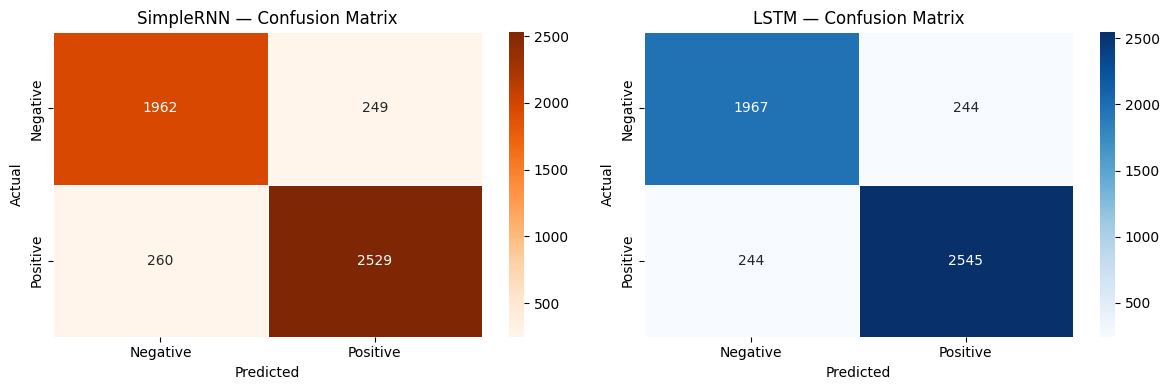

In [39]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Negative', 'Positive']
for ax, preds, name, cmap in zip(axes, [rnn_preds, lstm_preds],
                                  ['SimpleRNN', 'LSTM'], ['Oranges', 'Blues']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax, linewidths=0.5)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [40]:
# Classification reports
for name, preds in [('SimpleRNN', rnn_preds), ('LSTM', lstm_preds)]:
    print("=" * 45)
    print(f"  {name} — Classification Report")
    print("=" * 45)
    print(classification_report(y_test, preds, target_names=labels))


  SimpleRNN — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      2211
    Positive       0.91      0.91      0.91      2789

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      2211
    Positive       0.91      0.91      0.91      2789

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



## 10. Comparison

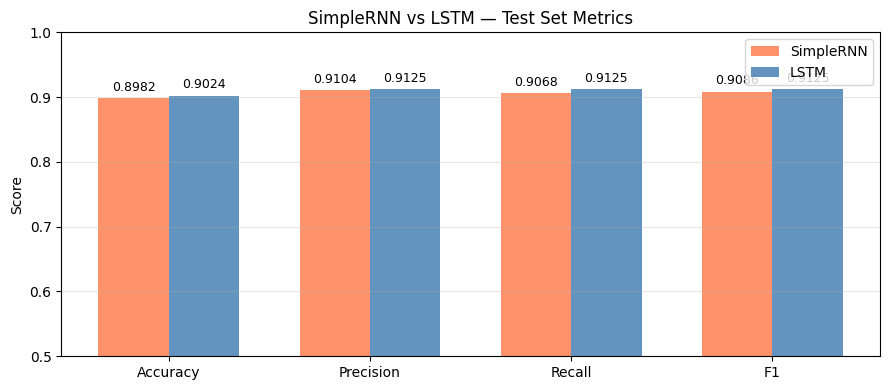

In [41]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
rnn_vals  = [rnn_metrics[m]  for m in metrics]
lstm_vals = [lstm_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, rnn_vals,  width, label='SimpleRNN', color='coral',     alpha=0.85)
b2 = ax.bar(x + width/2, lstm_vals, width, label='LSTM',      color='steelblue', alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('SimpleRNN vs LSTM — Test Set Metrics')
ax.legend()
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Discussion & Conclusion

### Why LSTM outperforms SimpleRNN

| Issue | SimpleRNN | LSTM |
|---|---|---|
| Vanishing gradient | Gradients shrink exponentially over time steps | Cell state acts as a gradient highway |
| Long-range memory | Forgets distant words quickly | Forget/input gates retain relevant context |
| Parameters | Fewer (faster) | ~4× more per unit (slower but smarter) |

### Key takeaways
- LSTM consistently achieves higher accuracy and F1 due to its gated memory cells.
- For very short sentences (SST-2 avg ~10 words), the gap is modest — on longer texts it widens significantly.
- Both models benefit from early stopping and learning rate reduction.
- Next steps: Bidirectional LSTM, stacked layers, or pre-trained GloVe embeddings for further improvement.
